# TFT Stock Return Prediction

In [1]:
# import subprocess, sys
# from pathlib import Path

# requirements_candidates = [Path('../requirements.txt'), Path('requirements.txt'), Path('../../backend/requirements.txt')]
# REQUIREMENTS_FILE = next(
#     candidate.resolve()
#     for candidate in requirements_candidates
#     if candidate.exists()
# )
# print(f'Installing packages from {REQUIREMENTS_FILE}')
# subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-r', str(REQUIREMENTS_FILE), '-q'])
# print('Done!')

## Run this is import fails


In [2]:
import pandas as pd
import numpy as np
import json
import warnings
from pathlib import Path
from datetime import datetime, timezone
import torch
import plotly.graph_objects as go
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss
from sklearn.metrics import mean_absolute_error, mean_squared_error
from IPython.display import display


In [3]:
warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)

In [4]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
TRAINER_ACCELERATOR = 'gpu' if DEVICE.type == 'cuda' else 'cpu'
print(f'Using device: {DEVICE}')

Using device: cpu


In [5]:
RETRAIN = False
MODEL_VERSION = None

# Training and model configuration
BATCH_SIZE = 32
NUM_WORKERS = 0
MAX_EPOCHS = 5
LEARNING_RATE = 0.001
HIDDEN_SIZE = 64
ATTENTION_HEAD_SIZE = 4
HIDDEN_CONTINUOUS_SIZE = 32
DROPOUT = 0.1
REDUCE_ON_PLATEAU_PATIENCE = 5
EARLY_STOPPING_PATIENCE = 5
GRADIENT_CLIP_VAL = 0.1
ENCODER_LENGTH = 12
PREDICTION_LENGTH = 1

In [6]:
REPO = Path('../../').resolve()
CSV_RAW = REPO / 'data/processed/final/stock_macro_monthly_target.csv'
CSV_MODEL = REPO / 'data/processed/final/stock_macro_monthly_model.csv'
MODEL_ROOT = REPO / 'backend/models/tft'
LEGACY_MODEL_ROOT = REPO / 'models/tft'
LEGACY_MODEL_PATH = LEGACY_MODEL_ROOT / 'tft_model.pt'
MODEL_ROOT.mkdir(parents=True, exist_ok=True)

version_dirs = sorted(
    [
        path for path in MODEL_ROOT.glob('v*')
        if path.is_dir() and path.name[1:].isdigit()
    ],
    key=lambda path: int(path.name[1:]),
)
available_versions = [int(path.name[1:]) for path in version_dirs]

if RETRAIN:
    MODEL_VERSION = (max(available_versions) + 1) if available_versions else 1
elif MODEL_VERSION is None:
    if available_versions:
        MODEL_VERSION = max(available_versions)
    elif LEGACY_MODEL_PATH.exists():
        MODEL_VERSION = 0
        print('No versioned model found; using legacy model at models/tft/tft_model.pt')
    else:
        raise FileNotFoundError(
            f'No saved model versions found under {MODEL_ROOT}. Set RETRAIN = True first.'
        )
elif MODEL_VERSION not in available_versions:
    raise FileNotFoundError(
        f'Model version v{MODEL_VERSION} was not found under {MODEL_ROOT}. '
        f'Available versions: {available_versions}'
    )

if MODEL_VERSION == 0:
    MODEL_DIR = MODEL_ROOT
else:
    MODEL_DIR = MODEL_ROOT / f'v{MODEL_VERSION}'

MODEL_PATH = LEGACY_MODEL_PATH if MODEL_VERSION == 0 else MODEL_DIR / 'tft_model.pt'
LOSS_HISTORY_PATH = MODEL_DIR / 'loss_history.json'
MODEL_METADATA_PATH = MODEL_DIR / 'model_metadata.json'
CHECKPOINT_DIR = MODEL_ROOT / '_checkpoints'

print(f'Available model versions: {available_versions or "none"}')
print(f'Using model version: {"legacy" if MODEL_VERSION == 0 else f"v{MODEL_VERSION}"}')
print(f'Retrain enabled: {RETRAIN}')

Available model versions: [1]
Using model version: v1
Retrain enabled: False


In [7]:
df = pd.read_csv(CSV_RAW)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['isin', 'date']).reset_index(drop=True)
print(f'Loaded: {df.shape[0]} rows, {df["isin"].nunique()} stocks')

Loaded: 60846 rows, 437 stocks


In [8]:
# Calculate returns and target
df['stock_return_1m'] = df.groupby('isin')['monthly_open'].pct_change() * 100
df['target_return_1m'] = df.groupby('isin')['stock_return_1m'].shift(-1)
df = df.dropna(subset=['stock_return_1m', 'target_return_1m']).reset_index(drop=True)
print(f'After dropna: {df.shape[0]} rows')

After dropna: 59972 rows


In [9]:
# Add stock-specific technical features
g = df.groupby('isin')['stock_return_1m']
df['momentum_3m'] = g.transform(lambda s: s.rolling(3, min_periods=1).sum()).fillna(0).clip(-500, 500)
df['momentum_6m'] = g.transform(lambda s: s.rolling(6, min_periods=1).sum()).fillna(0).clip(-500, 500)
df['momentum_12m'] = g.transform(lambda s: s.rolling(12, min_periods=1).sum()).fillna(0).clip(-500, 500)
df['volatility_3m'] = g.transform(lambda s: s.rolling(3, min_periods=2).std()).fillna(0).clip(0, 200)
df['volatility_6m'] = g.transform(lambda s: s.rolling(6, min_periods=2).std()).fillna(0).clip(0, 200)
df['volume_change_1m'] = df.groupby('isin')['monthly_volume'].transform(lambda s: s.pct_change() * 100).fillna(0).clip(-500, 500)

print('Added technical features')

Added technical features


In [10]:
# Select features
features = ['monthly_volume', 'oil_price_usd_bbl', 'oil_return_1m_pct', 'oil_return_12m_pct',
            'gold_price_inr_10g', 'gold_return_1m_pct', 'gold_return_12m_pct',
            'cpi_index', 'cpi_inflation_yoy_pct', 'stock_return_1m',
            'momentum_3m', 'momentum_6m', 'momentum_12m',
            'volatility_3m', 'volatility_6m',
            'volume_change_1m']

df = df[['isin', 'symbol', 'date'] + features + ['target_return_1m']].copy()

# Temporal split
train = df[df['date'] <= pd.Timestamp('2021-08-01')].copy()
val = df[(df['date'] > pd.Timestamp('2021-08-01')) & (df['date'] <= pd.Timestamp('2024-02-01'))].copy()
test = df[df['date'] > pd.Timestamp('2024-02-01')].copy()

print(f'Train: {len(train)}, Val: {len(val)}, Test: {len(test)}')

Train: 37399, Val: 10635, Test: 11938


In [11]:
# Median impute from train only
impute = {col: train[col].median() for col in features}
for df_split in [train, val, test]:
    df_split[features] = df_split[features].fillna(impute)
print('Imputation complete')

Imputation complete


In [12]:
# Create time_idx and series_id
min_date = df['date'].min()

for df_split in [train, val, test]:
    df_split['time_idx'] = (df_split['date'].dt.year - min_date.year) * 12 + (df_split['date'].dt.month - min_date.month)

all_isins_sorted = sorted(df['isin'].unique())
isin_to_series = {isin: i for i, isin in enumerate(all_isins_sorted)}

for df_split in [train, val, test]:
    df_split['series_id'] = df_split['isin'].map(isin_to_series).astype(int)
    df_split.sort_values(['series_id', 'time_idx'], inplace=True)
    df_split.reset_index(drop=True, inplace=True)

# Filter series with sufficient history
min_ts = 13
train = train.groupby('series_id').filter(lambda x: len(x) >= min_ts).reset_index(drop=True)
val = val.groupby('series_id').filter(lambda x: len(x) >= min_ts).reset_index(drop=True)
test = test.groupby('series_id').filter(lambda x: len(x) >= min_ts).reset_index(drop=True)

# Ensure val/test only use series from train
valid_series = set(train['series_id'].unique())
val = val[val['series_id'].isin(valid_series)].reset_index(drop=True)
test = test[test['series_id'].isin(valid_series)].reset_index(drop=True)

print(f'Train: {len(train)} rows, {train["series_id"].nunique()} series')
print(f'Val:   {len(val)} rows, {val["series_id"].nunique()} series')
print(f'Test:  {len(test)} rows, {test["series_id"].nunique()} series')

Train: 37315 rows, 313 series
Val:   9388 rows, 313 series
Test:  9360 rows, 312 series


In [13]:
# Save processed data
df.to_csv(CSV_MODEL, index=False)
print(f'Saved modeling dataset to {CSV_MODEL}')

Saved modeling dataset to C:\work\projects\PIC\data\processed\final\stock_macro_monthly_model.csv


In [14]:

# Convert series_id to string for static categorical
for df_split in [train, val, test]:
    df_split['series_id'] = df_split['series_id'].astype(str)

training_dataset = TimeSeriesDataSet(
    train,
    time_idx='time_idx',
    target='target_return_1m',
    group_ids=['series_id'],
    min_encoder_length=ENCODER_LENGTH,
    max_encoder_length=ENCODER_LENGTH,
    max_prediction_length=PREDICTION_LENGTH,
    static_categoricals=['series_id'],
    time_varying_unknown_reals=features,
    target_normalizer=GroupNormalizer(groups=['series_id']),
    allow_missing_timesteps=True,
    add_relative_time_idx=True,
)

validation_dataset = TimeSeriesDataSet.from_dataset(training_dataset, val, predict=False, stop_randomization=True)

print(f'Train sequences: {len(training_dataset)}')
print(f'Val sequences: {len(validation_dataset)}')

Train sequences: 33559
Val sequences: 5632


In [15]:
# Create DataLoaders
train_dataloader = training_dataset.to_dataloader(train=True, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS)
val_dataloader = validation_dataset.to_dataloader(train=False, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS)

# Verify batch shapes
x, y = next(iter(train_dataloader))
print(f'Batch shapes verified')
print(f'  Encoder input (encoder_cont): {x["encoder_cont"].shape}')
print(f'  Target: {y[0].shape}')
print(f'Train batches: {len(train_dataloader)}, Val batches: {len(val_dataloader)}')

Batch shapes verified
  Encoder input (encoder_cont): torch.Size([32, 12, 17])
  Target: torch.Size([32, 1])
Train batches: 1048, Val batches: 176


In [16]:
tft = TemporalFusionTransformer.from_dataset(
    training_dataset,
    learning_rate=LEARNING_RATE,
    hidden_size=HIDDEN_SIZE,
    attention_head_size=ATTENTION_HEAD_SIZE,
    hidden_continuous_size=HIDDEN_CONTINUOUS_SIZE,
    dropout=DROPOUT,
    loss=QuantileLoss(),
    reduce_on_plateau_patience=REDUCE_ON_PLATEAU_PATIENCE,
)

total_params = sum(p.numel() for p in tft.parameters())
print(f'TFT Model created')
print(f'  Parameters: {total_params:,}')

TFT Model created
  Parameters: 352,411


In [17]:
# Handle Lightning namespace compatibility
lightning_root = None
for base in type(tft).__mro__:
    if base.__name__ == 'LightningModule':
        lightning_root = base.__module__.split('.')[0]
        break

print(f'Detected Lightning namespace: {lightning_root}')

if lightning_root == 'lightning':
    import lightning.pytorch as pl
    from lightning.pytorch import Trainer
    from lightning.pytorch.callbacks import Callback, EarlyStopping, ModelCheckpoint
else:
    import pytorch_lightning as pl
    from pytorch_lightning import Trainer
    from pytorch_lightning.callbacks import Callback, EarlyStopping, ModelCheckpoint

class LossHistory(Callback):
    def __init__(self):
        self.train_losses = []
        self.val_losses = []

    def on_train_epoch_end(self, trainer, pl_module):
        loss = trainer.callback_metrics.get('train_loss')
        if loss is not None:
            self.train_losses.append(float(loss.detach().cpu()))

    def on_validation_epoch_end(self, trainer, pl_module):
        val_loss = trainer.callback_metrics.get('val_loss')
        if val_loss is not None:
            self.val_losses.append(float(val_loss.detach().cpu()))

loss_history = LossHistory()

early_stop = EarlyStopping(monitor='val_loss', patience=EARLY_STOPPING_PATIENCE, verbose=True, mode='min')
checkpoint = ModelCheckpoint(
    dirpath=str(CHECKPOINT_DIR),
    filename='best-{epoch:02d}-{val_loss:.4f}',
    monitor='val_loss',
    mode='min',
    save_top_k=1,
)

trainer = Trainer(
    max_epochs=MAX_EPOCHS,
    callbacks=[early_stop, checkpoint, loss_history],
    gradient_clip_val=GRADIENT_CLIP_VAL,
    accelerator=TRAINER_ACCELERATOR,
    devices=1,
    logger=False,
    enable_progress_bar=True,
)

print('Trainer configured')

Detected Lightning namespace: lightning


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Trainer configured


In [18]:
# Train or load model
if RETRAIN:
    print('Starting training...')
    CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
    trainer.fit(tft, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)
    print('Training complete')

    if not checkpoint.best_model_path:
        raise RuntimeError('No best validation checkpoint was created')

    best_checkpoint = torch.load(
        checkpoint.best_model_path,
        map_location=DEVICE,
        weights_only=False,
    )
    tft.load_state_dict(best_checkpoint['state_dict'])
    best_epoch = int(best_checkpoint['epoch'])
    best_val_loss = float(checkpoint.best_model_score.detach().cpu())

    MODEL_DIR.mkdir(parents=True, exist_ok=True)
    torch.save(tft.state_dict(), MODEL_PATH)
    LOSS_HISTORY_PATH.write_text(json.dumps({
        'train_losses': loss_history.train_losses,
        'val_losses': loss_history.val_losses,
        'best_epoch': best_epoch,
        'best_val_loss': best_val_loss,
    }))
    MODEL_METADATA_PATH.write_text(json.dumps({
        'version': f'v{MODEL_VERSION}',
        'saved_at_utc': datetime.now(timezone.utc).isoformat(),
        'model_type': 'TemporalFusionTransformer',
        'framework': 'pytorch-forecasting',
        'features': features,
        'target': 'target_return_1m',
        'encoder_length': ENCODER_LENGTH,
        'prediction_length': PREDICTION_LENGTH,
        'hidden_size': HIDDEN_SIZE,
        'attention_head_size': ATTENTION_HEAD_SIZE,
        'hidden_continuous_size': HIDDEN_CONTINUOUS_SIZE,
        'dropout': DROPOUT,
        'learning_rate': LEARNING_RATE,
        'max_epochs': MAX_EPOCHS,
        'train_rows': len(train),
        'validation_rows': len(val),
        'best_epoch': best_epoch,
        'best_val_loss': best_val_loss,
        'source_checkpoint': checkpoint.best_model_path,
    }, indent=2))
    print(f'Model saved to {MODEL_PATH}')
    print(f'Loss history saved to {LOSS_HISTORY_PATH}')
    print(f'Model metadata saved to {MODEL_METADATA_PATH}')
else:
    if not MODEL_PATH.exists():
        raise FileNotFoundError(
            f'No saved model found at {MODEL_PATH}. Set RETRAIN = True first.'
        )

    tft.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    tft.to(DEVICE)
    tft.eval()

    if LOSS_HISTORY_PATH.exists():
        saved_history = json.loads(LOSS_HISTORY_PATH.read_text())
        loss_history.train_losses = saved_history.get('train_losses', [])
        loss_history.val_losses = saved_history.get('val_losses', [])
        best_epoch = saved_history.get('best_epoch')
        best_val_loss = saved_history.get('best_val_loss')
        if best_epoch is None and loss_history.val_losses:
            best_epoch = int(np.argmin(loss_history.val_losses)) + 1
            best_val_loss = loss_history.val_losses[best_epoch - 1]
        print(f'Best validation epoch: {best_epoch}, loss: {best_val_loss}')
        print(f'Loaded loss history from {LOSS_HISTORY_PATH}')
    else:
        print(
            f'No saved loss history found at {LOSS_HISTORY_PATH}. '
            'Loss curves will be unavailable for this model.'
        )

    print(f'Loaded model from {MODEL_PATH}; training skipped')

Best validation epoch: 4, loss: 4.237197399139404
Loaded loss history from C:\work\projects\PIC\backend\models\tft\v1\loss_history.json
Loaded model from C:\work\projects\PIC\backend\models\tft\v1\tft_model.pt; training skipped


In [19]:
# Evaluate on test set
test_dataset = TimeSeriesDataSet.from_dataset(training_dataset, test, predict=False, stop_randomization=True)
test_dataloader = test_dataset.to_dataloader(train=False, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS)

tft.eval()
tft.to(DEVICE)
predictions = []
actuals = []
prediction_indices = []

with torch.no_grad():
    for x, y in test_dataloader:
        x = {
            name: value.to(DEVICE) if torch.is_tensor(value) else value
            for name, value in x.items()
        }
        y_pred = tft(x)['prediction'][:, 0, 1]  # median (0.5 quantile)
        y_true = y[0].squeeze(-1)
        predictions.append(y_pred.cpu().numpy())
        actuals.append(y_true.cpu().numpy())
        prediction_indices.append(test_dataset.x_to_index(x))

predictions = np.concatenate(predictions).flatten()
actuals = np.concatenate(actuals).flatten()
prediction_indices = pd.concat(prediction_indices, ignore_index=True)

if len(prediction_indices) != len(predictions):
    raise ValueError(
        f'Prediction index length ({len(prediction_indices)}) does not match '
        f'prediction length ({len(predictions)})'
    )

print(f'Predictions shape: {predictions.shape}')
print(f'Actuals shape: {actuals.shape}')

# Calculate basic metrics
mae = mean_absolute_error(actuals, predictions)
rmse = np.sqrt(mean_squared_error(actuals, predictions))
print(f'Test MAE: {mae:.4f}')
print(f'Test RMSE: {rmse:.4f}')

Predictions shape: (5616,)
Actuals shape: (5616,)
Test MAE: 10.2694
Test RMSE: 13.5440


## Training diagnostics and company-level forecast plots

This section shows training/validation loss curves and lets you inspect actual-vs-predicted behavior for any company in the test set.

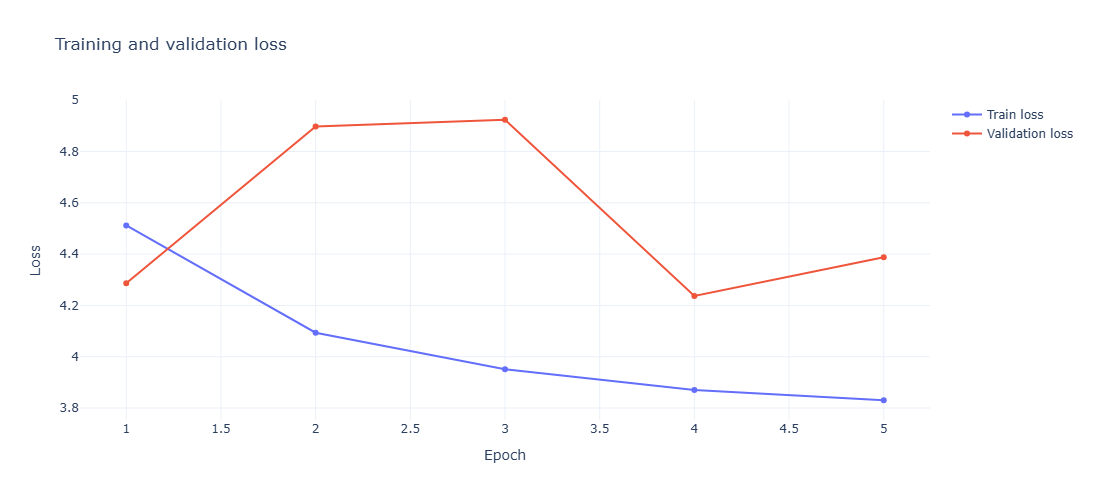

In [20]:
# Plot training and validation loss curves when the Trainer callback was run

loss_history = globals().get('loss_history')
train_losses = getattr(loss_history, 'train_losses', [])
val_losses = getattr(loss_history, 'val_losses', [])

if len(train_losses) > 0 or len(val_losses) > 0:
    loss_fig = go.Figure()
    if len(train_losses) > 0:
        loss_fig.add_trace(go.Scatter(
            x=list(range(1, len(train_losses) + 1)),
            y=train_losses,
            mode='lines+markers',
            name='Train loss'
        ))
    if len(val_losses) > 0:
        loss_fig.add_trace(go.Scatter(
            x=list(range(1, len(val_losses) + 1)),
            y=val_losses,
            mode='lines+markers',
            name='Validation loss'
        ))
    loss_fig.update_layout(
        title='Training and validation loss',
        xaxis_title='Epoch',
        yaxis_title='Loss',
        template='plotly_white',
        height=500,
    )
    loss_fig.show()
else:
    print('Loss history is unavailable. Run the Trainer setup and training cells first.')

## TFT feature importance and interpretation plots
These are the feature-importance and attention plots provided by the trained TFT model.


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


TFT interpretation plots:
  - attention


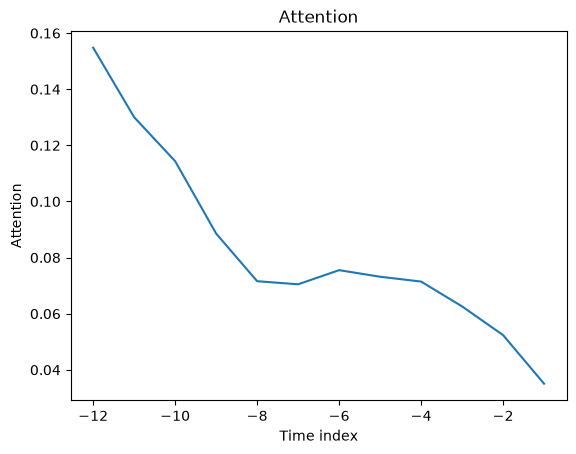

  - static_variables


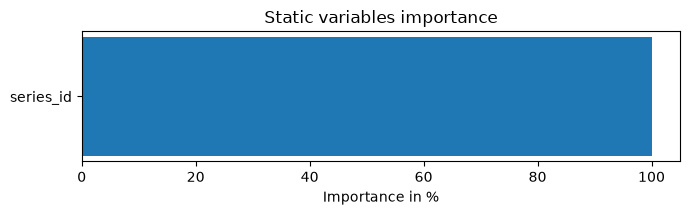

  - encoder_variables


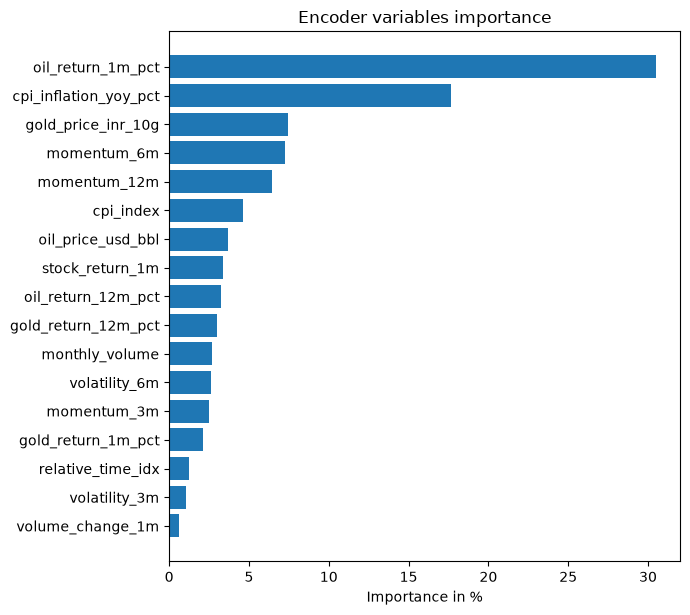

  - decoder_variables


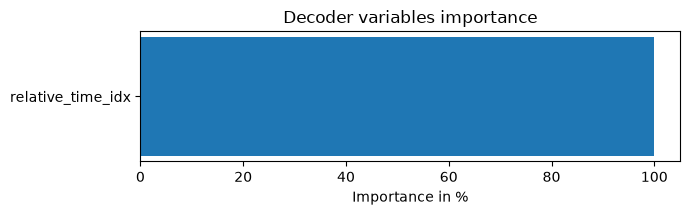

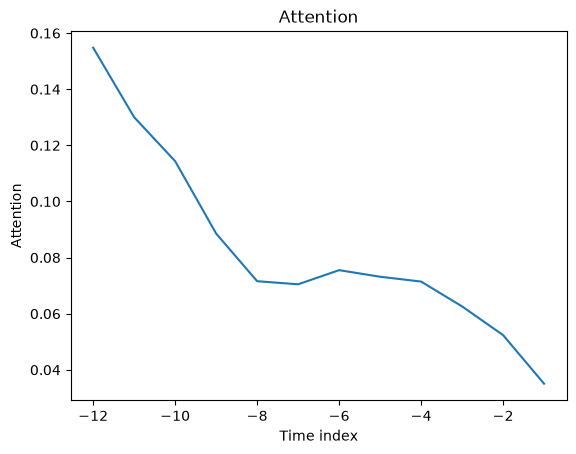

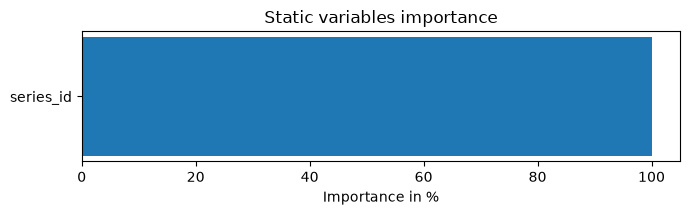

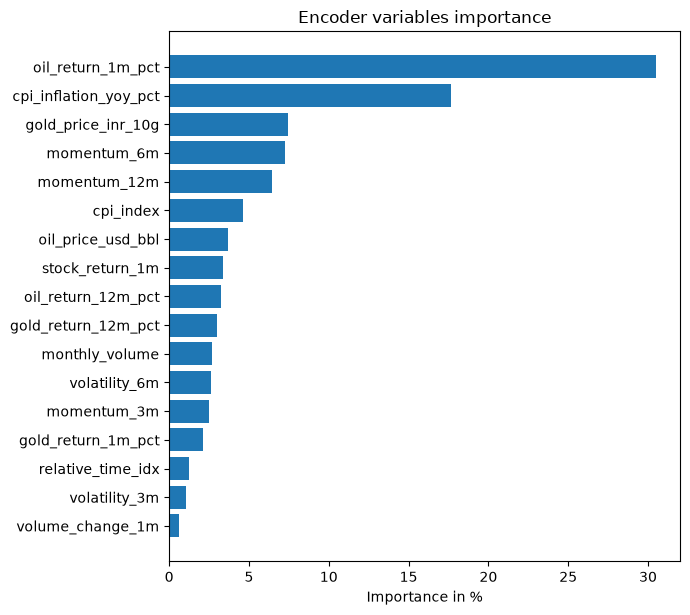

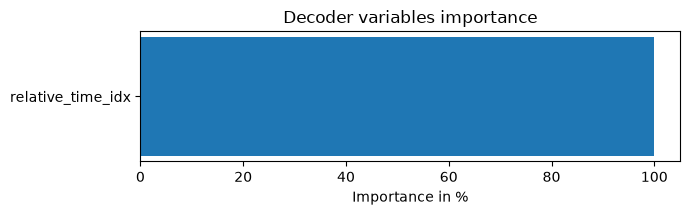

In [21]:
# Generate TFT-native feature importance and attention plots

raw_validation_predictions = tft.predict(
    val_dataloader,
    mode='raw',
    return_x=True,
    trainer_kwargs={'accelerator': TRAINER_ACCELERATOR, 'devices': 1},
)

interpretation = tft.interpret_output(
    raw_validation_predictions.output,
    reduction='sum',
)
interpretation_figures = tft.plot_interpretation(interpretation)

print('TFT interpretation plots:')
for plot_name, figure in interpretation_figures.items():
    print(f'  - {plot_name}')
    display(figure)


In [22]:
def plot_company_predictions(company_name):
    company_df = test_eval[test_eval['symbol'] == company_name].sort_values('date').copy()
    if company_df.empty:
        raise ValueError(f'Company not found: {company_name}')

    mae = mean_absolute_error(company_df['actual'], company_df['predicted'])
    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=company_df['date'],
        y=company_df['actual'],
        mode='lines+markers',
        name='Actual',
        line=dict(color='royalblue', width=2)
    ))
    fig.add_trace(go.Scatter(
        x=company_df['date'],
        y=company_df['predicted'],
        mode='lines+markers',
        name='Predicted',
        line=dict(color='firebrick', width=2)
    ))
    fig.update_layout(
        title=f'{company_name} actual vs predicted returns | MAE={mae:.4f}',
        xaxis_title='Date',
        yaxis_title='Return (%)',
        template='plotly_white',
        height=500,
    )
    return fig


def plot_top_companies(top_n=5):
    summary = (
        test_eval.groupby('symbol')
        .apply(lambda g: mean_absolute_error(g['actual'], g['predicted']))
        .rename('mae')
        .sort_values()
        .head(top_n)
    )
    print('Top companies by MAE:')
    print(summary)
    for company in summary.index:
        plot_company_predictions(company).show()
    return summary

# Example usage:
# plot_company_predictions('RELIANCE')
# plot_top_companies(5)

In [23]:
# Align each forecast with its decoder date and company. The test dataframe
# contains raw rows, while the dataset returns one row per forecast window.
test_metadata = test[['series_id', 'time_idx', 'symbol', 'date']].copy()
test_eval = prediction_indices.merge(
    test_metadata,
    on=['series_id', 'time_idx'],
    how='left',
    validate='one_to_one',
)
test_eval['actual'] = actuals
test_eval['predicted'] = predictions
test_eval['abs_error'] = (test_eval['actual'] - test_eval['predicted']).abs()
test_eval['date'] = pd.to_datetime(test_eval['date'])

if test_eval[['symbol', 'date']].isna().any().any():
    raise ValueError('Some predictions could not be matched to test metadata')

available_companies = sorted(test_eval['symbol'].dropna().unique())
print('Available companies:')
for company in available_companies:
    print(f'  - {company}')

Available companies:
  - AARTIIND
  - AAVAS
  - ABB
  - ABBOTINDIA
  - ABREL
  - ACC
  - ADANIENT
  - ADANIPORTS
  - AFFLE
  - AJANTPHARM
  - ALKEM
  - AMBUJACEM
  - ANUP
  - APARINDS
  - APOLLOHOSP
  - APOLLOTYRE
  - ARVIND
  - ASAHIINDIA
  - ASHIANA
  - ASHOKLEY
  - ASIANPAINT
  - ASTEC
  - ASTERDM
  - ASTRAMICRO
  - ASTRAZEN
  - AUBANK
  - AUROPHARMA
  - AUTOAXLES
  - AXISBANK
  - BAJAJ-AUTO
  - BAJAJCON
  - BAJAJELEC
  - BAJAJFINSV
  - BAJFINANCE
  - BALKRISIND
  - BALRAMCHIN
  - BANDHANBNK
  - BANKBARODA
  - BANKINDIA
  - BAYERCROP
  - BDL
  - BEL
  - BEML
  - BHARATFORG
  - BHARTIARTL
  - BHEL
  - BIOCON
  - BIRLACORPN
  - BLUEDART
  - BLUESTARCO
  - BOSCHLTD
  - BPCL
  - BRIGADE
  - BRITANNIA
  - BSE
  - BSOFT
  - CANFINHOME
  - CARBORUNIV
  - CARERATING
  - CASTROLIND
  - CDSL
  - CENTURYPLY
  - CESC
  - CHALET
  - CHAMBLFERT
  - CHOLAFIN
  - CIEINDIA
  - CIPLA
  - COALINDIA
  - COLPAL
  - CONCOR
  - COROMANDEL
  - CREDITACC
  - CRISIL
  - CROMPTON
  - CUB
  - CUMMINSIND
  - CY

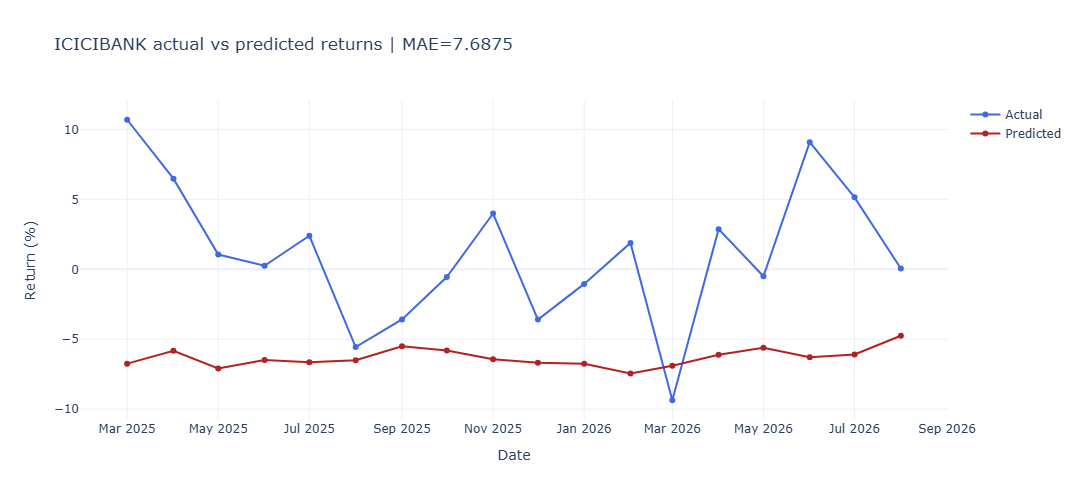

In [24]:
plot_company_predictions('ICICIBANK')

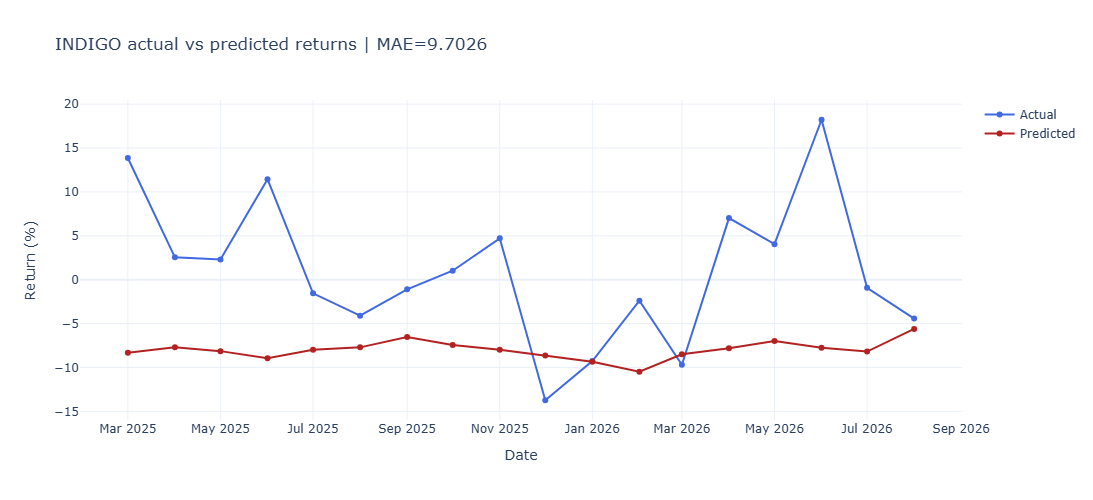

In [25]:
plot_company_predictions('INDIGO')

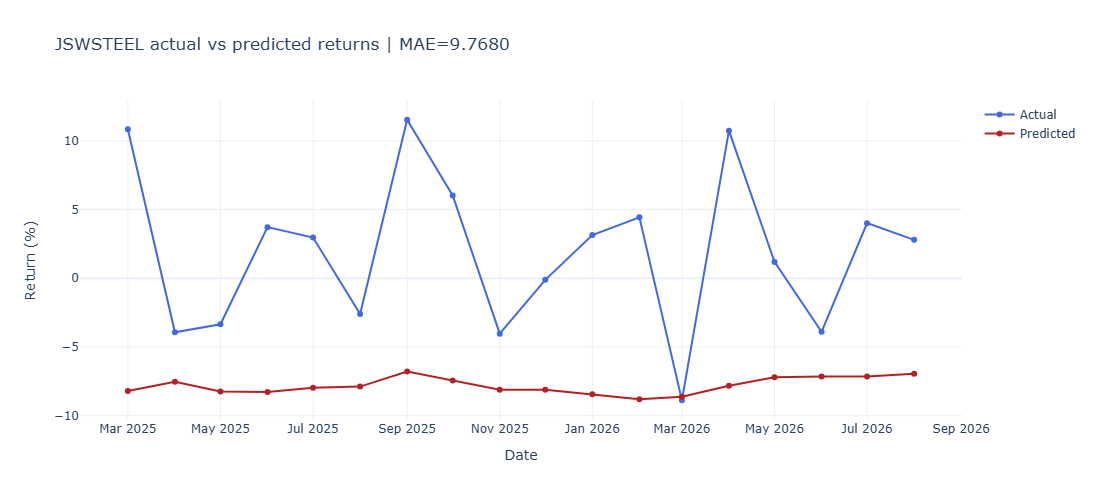

In [26]:
plot_company_predictions('JSWSTEEL')

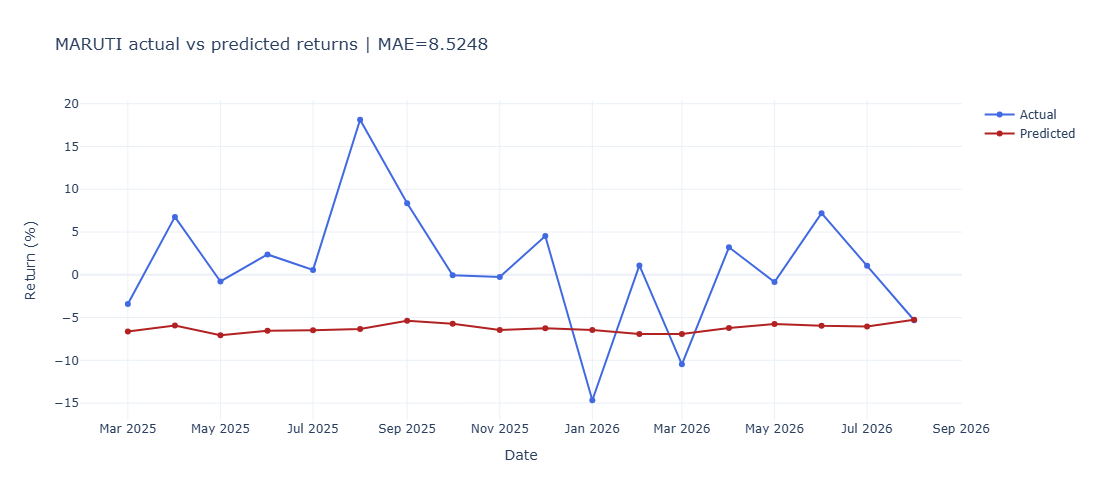

In [27]:
plot_company_predictions('MARUTI')

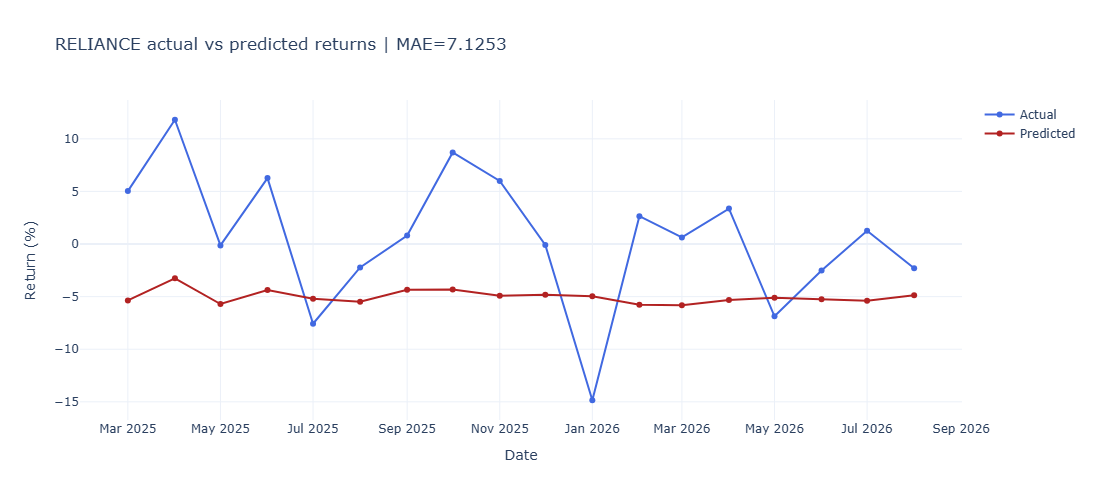

In [28]:
plot_company_predictions('RELIANCE')

In [29]:
print(f'Model workflow completed for {"legacy" if MODEL_VERSION == 0 else f"v{MODEL_VERSION}"}')

Model workflow completed for v1
